In [ ]:

import sympy as sp
from sympy import Matrix, sqrt, I
from sympy.physics.quantum import Dagger

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D


#rc params five38
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (10, 6)




### Problem 1
- Theory and Sims for Comp, Cirular, and Han. basis

In [4]:
#theory probabilities as and functs
def pz(phi):
    return 0.5, 0.5

def px(phi):
    return 0.5*(1+np.cos(phi)), 0.5*(1-np.cos(phi))

def py(phi):
    return 0.5*(1+np.sin(phi)), 0.5*(1-np.sin(phi))

import numpy as np
import matplotlib.pyplot as plt

#sim one basis
def sample_basis(phi, basis='z', shots=2000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    if basis=='z':
        p0, p1 = 0.5, 0.5
    elif basis=='x':
        p0, p1 = 0.5*(1+np.cos(phi)), 0.5*(1-np.cos(phi))
    elif basis=='y':
        p0, p1 = 0.5*(1+np.sin(phi)), 0.5*(1-np.sin(phi))
    else:
        raise ValueError('bad basis')
    k = rng.binomial(shots, p0)
    return k/shots, 1-k/shots

phis = np.linspace(0, 2*np.pi, 257)

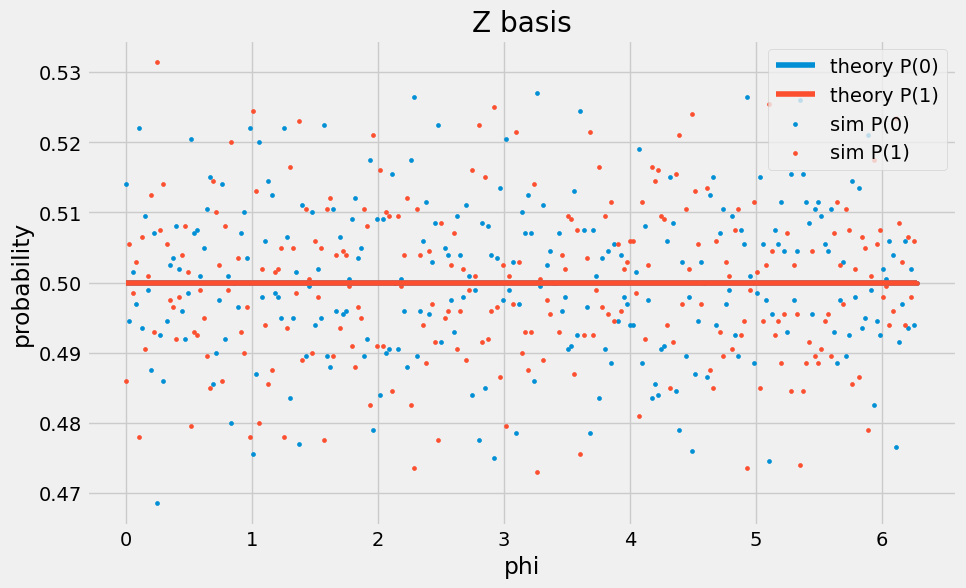

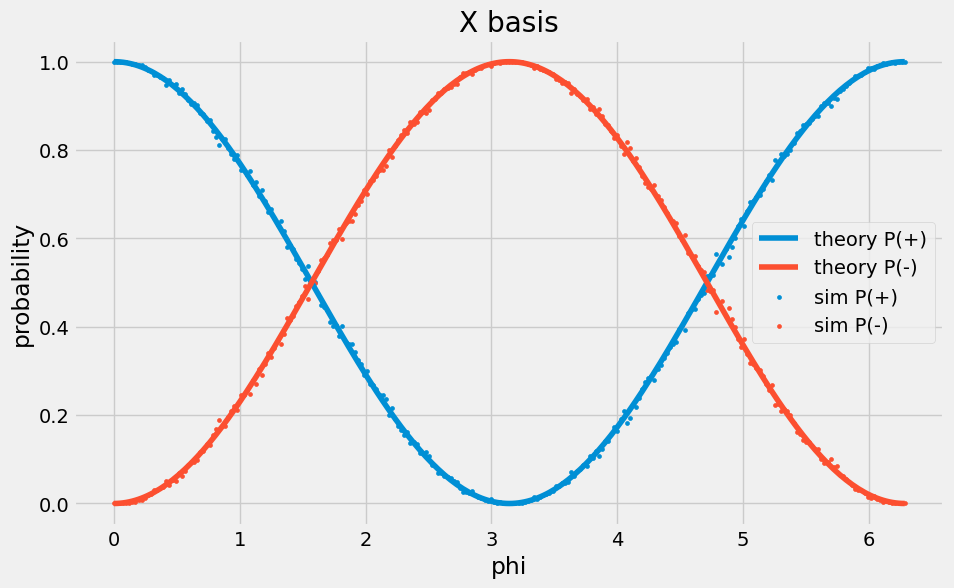

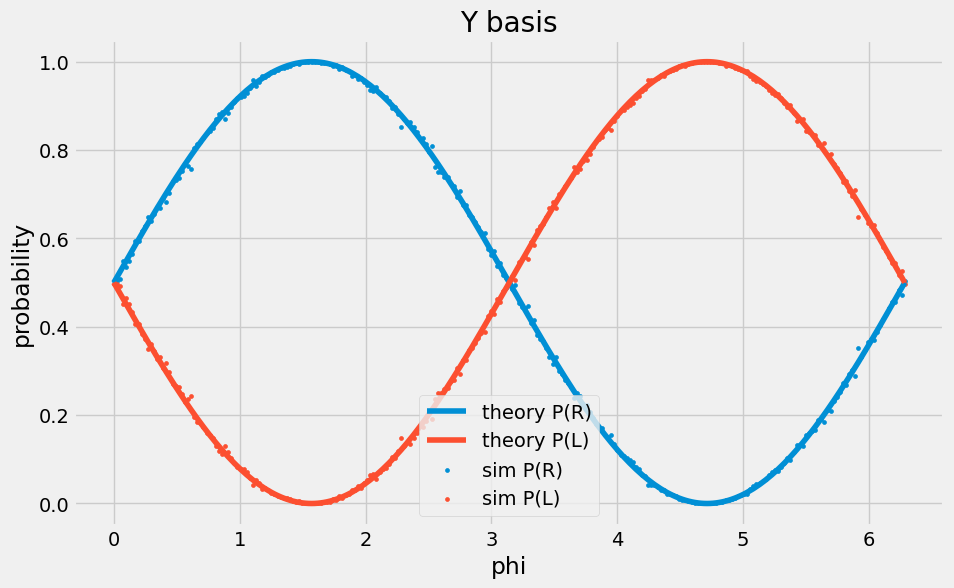

In [5]:
#Z
sim0, sim1 = zip(*[sample_basis(phi, 'z', shots=2000, rng=np.random.default_rng(i)) for i,phi in enumerate(phis)])
plt.figure()
plt.plot(phis, np.full_like(phis, 0.5), label='theory P(0)')
plt.plot(phis, np.full_like(phis, 0.5), label='theory P(1)')
plt.scatter(phis, sim0, s=8, label='sim P(0)')
plt.scatter(phis, sim1, s=8, label='sim P(1)')
plt.xlabel('phi'); plt.ylabel('probability'); plt.title('Z basis'); plt.legend(); plt.show()

#X
sim_plus, sim_minus = zip(*[sample_basis(phi, 'x', shots=2000, rng=np.random.default_rng(i+1000)) for i,phi in enumerate(phis)])
plt.figure()
plt.plot(phis, 0.5*(1+np.cos(phis)), label='theory P(+)')
plt.plot(phis, 0.5*(1-np.cos(phis)), label='theory P(-)')
plt.scatter(phis, sim_plus, s=8, label='sim P(+)')
plt.scatter(phis, sim_minus, s=8, label='sim P(-)')
plt.xlabel('phi'); plt.ylabel('probability'); plt.title('X basis'); plt.legend(); plt.show()

#Y
sim_r, sim_l = zip(*[sample_basis(phi, 'y', shots=2000, rng=np.random.default_rng(i+2000)) for i,phi in enumerate(phis)])
plt.figure()
plt.plot(phis, 0.5*(1+np.sin(phis)), label='theory P(R)')
plt.plot(phis, 0.5*(1-np.sin(phis)), label='theory P(L)')
plt.scatter(phis, sim_r, s=8, label='sim P(R)')
plt.scatter(phis, sim_l, s=8, label='sim P(L)')
plt.xlabel('phi'); plt.ylabel('probability'); plt.title('Y basis'); plt.legend(); plt.show()

## Prblem 2

In [22]:
#basis kets
zero = sp.Matrix([[1],[0]])
one = sp.Matrix([[0],[1]])

#hadamard in matrix form
H = (1/sp.sqrt(2))*sp.Matrix([[1,1],[1,-1]])

#bra-ket expansion equiv.
outer = lambda a,b: a * Dagger(b)
H_bk = (1/sp.sqrt(2))*(outer(zero,zero)+outer(zero,one) +outer(one,zero)-outer(one,one))
print("H =")
display(H)

print(f"Check if H and H_bk are equal\n: {H == H_bk}\n")


H =


Matrix([
[sqrt(2)/2,  sqrt(2)/2],
[sqrt(2)/2, -sqrt(2)/2]])

Check if H and H_bk are equal
: True



In [23]:
# apply
H0 = H * zero
H1 = H * one

#target +/- states
plus = (zero+one)/sp.sqrt(2)
minus = (zero-one)/sp.sqrt(2)

print('H | 0> =')
display(H0)
print('H | 1> =')
display(H1)
print('overlaps:')
print('⟨+|H|0⟩ = ', (Dagger(plus) * H0)[0])
print('⟨-|H|1⟩ =' , (Dagger(minus) * H1)[0])


H | 0> =


Matrix([
[sqrt(2)/2],
[sqrt(2)/2]])

H | 1> =


Matrix([
[ sqrt(2)/2],
[-sqrt(2)/2]])

overlaps:
⟨+|H|0⟩ =  1
⟨-|H|1⟩ = 1


## Problem 3: Explain to gma (will come back to this;)

## problem 4;
- exploration of H

In [30]:
#std. hadamard
H_sym = (1/sp.sqrt(2))*sp.Matrix([[1, 1], [1, -1]])
print('H =')
display(H_sym)
# (a) unitary check: H†H
unitary_check = Dagger(H_sym) * H_sym
print('H†H =')
display(unitary_check)

# (b) self-inverse check: H^2
self_inverse = H_sym * H_sym
print('H^2 =')
display(self_inverse)

# (c) eigenpairs
eigen_data = H_sym.eigenvects()
print('Eigenvalues and eigenvectors:')
for val, mult, vecs in eigen_data:
    print(f'Eigenvalue: {val}')
    print('Eigenvector(s):')
    for v in vecs:
        display(v)
        
#bonus: bra-ket expansion as operator sum
ket0 = sp.Matrix([[1],[0]])
ket1 = sp.Matrix([[0],[1]])
outer = lambda a,b: a*b.T
H_bk = (1/sp.sqrt(2))*(outer(ket0,ket0)+outer(ket0,ket1)+outer(ket1,ket0)-outer(ket1,ket1))
print('bra-ket equals matrix? ->', sp.simplify(H_sym - H_bk)==sp.zeros(2))

H =


Matrix([
[sqrt(2)/2,  sqrt(2)/2],
[sqrt(2)/2, -sqrt(2)/2]])

H†H =


Matrix([
[1, 0],
[0, 1]])

H^2 =


...

Eigenvalues and eigenvectors:
Eigenvalue: -1
Eigenvector(s):


Matrix([
[1 - sqrt(2)],
[          1]])

Eigenvalue: 1
Eigenvector(s):


Matrix([
[1 + sqrt(2)],
[          1]])

bra-ket equals matrix? -> True


In [27]:
#animate hadamard action on bloch sphere
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  #needed for 3d
from math import sin, cos, pi
from pathlib import Path
 
#no seaborn, one plot per figure
 
#np helpers
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=np.complex128)
ket0 = np.array([1,0], dtype=np.complex128)
ket1 = np.array([0,1], dtype=np.complex128)
 
def bloch_from_state(psi):
    #no space comments
    sx = np.array([[0,1],[1,0]], dtype=np.complex128)
    sy = np.array([[0,-1j],[1j,0]], dtype=np.complex128)
    sz = np.array([[1,0],[0,-1]], dtype=np.complex128)
    rho = np.outer(psi, np.conj(psi))
    x = np.real(np.trace(rho@sx))
    y = np.real(np.trace(rho@sy))
    z = np.real(np.trace(rho@sz))
    return np.array([x,y,z], float)
 
def slerp(a, b, t):
    #spherical interp for unit vectors
    a = a/np.linalg.norm(a)
    b = b/np.linalg.norm(b)
    dot = np.clip(np.dot(a,b), -1.0, 1.0)
    if 1-dot < 1e-9:
        return a
    th = np.arccos(dot)
    return (np.sin((1-t)*th)/np.sin(th))*a + (np.sin(t*th)/np.sin(th))*b
 
#states and images under H
plus = H@ket0
minus = H@ket1
 
r0 = bloch_from_state(ket0)   #north pole
r1 = bloch_from_state(ket1)   #south pole
rp = bloch_from_state(plus)   #+x
rm = bloch_from_state(minus)  #-x
 
#figure
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('hadamard maps |0>→|+>, |1>→|->')
 
#unit sphere wireframe
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(xs, ys, zs, linewidth=0.3, rstride=4, cstride=4, alpha=0.4)
 
#arrows (quivers)
q0 = ax.quiver(0,0,0, r0[0],r0[1],r0[2], length=1, arrow_length_ratio=0.08)
q1 = ax.quiver(0,0,0, r1[0],r1[1],r1[2], length=1, arrow_length_ratio=0.08)
qp = ax.quiver(0,0,0, rp[0],rp[1],rp[2], length=0, arrow_length_ratio=0.08)  #start hidden
qm = ax.quiver(0,0,0, rm[0],rm[1],rm[2], length=0, arrow_length_ratio=0.08)
 
#text labels
t0 = ax.text(r0[0], r0[1], r0[2], '|0>')
t1 = ax.text(r1[0], r1[1], r1[2], '|1>')
tp = ax.text(rp[0], rp[1], rp[2], '|+>')
tm = ax.text(rm[0], rm[1], rm[2], '|->')
 
def set_quiver(q, vec):
    #matplotlib quiver objects are static; remove and redraw
    q.remove()
    return ax.quiver(0,0,0, vec[0],vec[1],vec[2], length=1, arrow_length_ratio=0.08)
 
#frames: interpolate 0→1
frames = 60
 
def animate(k):
    t = k/(frames-1)
    r0_t = slerp(r0, rp, t)
    r1_t = slerp(r1, rm, t)
    global q0, q1, qp, qm
    q0 = set_quiver(q0, r0_t)
    q1 = set_quiver(q1, r1_t)
    qp = set_quiver(qp, rp) if k==frames-1 else set_quiver(qp, np.zeros(3))
    qm = set_quiver(qm, rm) if k==frames-1 else set_quiver(qm, np.zeros(3))
    return q0, q1, qp, qm
 
ani = animation.FuncAnimation(fig, animate, frames=frames, interval=40, blit=False)
 
#save gif using pillow writer
out = Path('hadamard_map.gif')
ani.save(out.as_posix(), writer=animation.PillowWriter(fps=25))
plt.close(fig)
print('saved', out.resolve())

saved /workspaces/hwsolutions/PHY7973/HW3/hadamard_map.gif
